# **Experiment Notebook**



In [97]:
# Do not modify this code
!pip install -q utstd

from utstd.ipyrenders import *

In [98]:
# Do not modify this code
import warnings
warnings.simplefilter(action='ignore')

In [99]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"

import pandas as pd

pd.__version__

'2.2.2'

---
## Student Information

In [100]:
# <Student to fill this section>
student_name = "Nishaanth Govindaraj"
student_id = "26044382"

In [101]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [102]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

In [103]:
# <Student to fill this section>
%load_ext autoreload
%autoreload 2

import json
import numpy as np
import matplotlib.pyplot as plt
from joblib import dump, load

from my_krml_26044382 import __version__ as package_version
from my_krml_26044382.data.weather import load_hourly_weather_years, aggregate_daily
from my_krml_26044382.data.sets import split_sets_by_time
from my_krml_26044382.features.targets import add_target_columns, create_future_targets, cci_to_label
from my_krml_26044382.features.build import build_features, get_feature_columns, REQUIRED_HISTORY_DAYS
from my_krml_26044382.models.performance import print_regressor_scores, get_feature_importance

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


---
## A. Project Description




In [104]:
# <Student to fill this section>
business_use_case_description = """
Open-Meteo is adding AI-powered weather intelligence services to its microservice platform. This project builds a
forecasting service that predicts the Climate Comfort Index (CCI) for Sydney for each of the next 3 days. The CCI
(0 to 100) summarises how suitable the weather is for outdoor activities by combining temperature, humidity, wind,
cloud cover and rainfall into one easy-to-read score.

The service will be exposed through a REST API so that consumer apps, tourism and events businesses can plan
outdoor activities in advance.

Experiments 1 (Ridge) and 2 (XGBoost) reached almost the same validation accuracy (RMSE about 8.5, 10.0 and
10.5 for days 1 to 3), both beating the baselines. However, both pull their forecasts towards the average: 78
percent of uncomfortable days (CCI below 60) were forecast as comfortable at day 1, and more than 99 percent at
days 2 and 3. XGBoost also overfitted (training RMSE 6.22 vs validation 8.52 for day 1).

Hypothesis for this final experiment: tuning XGBoost with Optuna (including regularisation parameters) and
giving more weight to uncomfortable days during training reduces the share of uncomfortable days missed, while
keeping the RMSE close to Experiment 2 and still beating Ridge and both baselines on the unseen test period
(2023-2025).
"""

In [105]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [106]:
# <Student to fill this section>
business_objectives = """
Accurate forecasts let users and businesses plan outdoor activities (events, tours, sport, hospitality staffing)
on the most comfortable days, and prepare alternatives for uncomfortable days.

Impact of accurate results: better event scheduling, fewer cancellations, higher customer satisfaction and
trust in the Open-Meteo platform.

Impact of incorrect results:
- Over-estimating comfort: an event is scheduled on a day that turns out uncomfortable or rainy, leading to
  cancellations, refunds, poor attendance or safety concerns. This is the more costly error.
- Under-estimating comfort: good days are missed, causing lost revenue and unnecessary rescheduling.

Success criterion: the model must beat both baselines on the validation set for all three horizons, with errors
small enough that the forecast usually falls in the correct CCI interpretation band.
"""

In [107]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [108]:
# <Student to fill this section>
stakeholders_expectations_explanations = """
Users of the predictions:
- Developers of apps and websites that consume the Open-Meteo API.
- Tourism operators, event organisers, sports clubs and hospitality businesses planning outdoor activities.
- Members of the public checking whether the next days suit outdoor plans.

People impacted by the predictions:
- Event attendees and customers, whose plans depend on the forecast.
- Staff whose rosters may be set from the forecast.
- The Open-Meteo business, whose reputation depends on forecast reliability.

Expectations: forecasts must be available on demand through the API, easy to interpret (the CCI bands from
Excellent to Very poor), and transparent about their accuracy, which is expected to decrease from day 1 to day 3.
"""

In [109]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

---
## C. Data Understanding

### C.1   Load Raw Data


In [110]:
# <Student to fill this section>
df_hourly = load_hourly_weather_years(2000, 2025, cache_dir='../../data/raw/yearly')
df_daily = aggregate_daily(df_hourly)

print(df_hourly.shape, df_daily.shape)
print(df_daily['date'].min(), df_daily['date'].max())

2000: loaded from cache
2001: loaded from cache
2002: loaded from cache
2003: loaded from cache
2004: loaded from cache
2005: loaded from cache
2006: loaded from cache
2007: loaded from cache
2008: loaded from cache
2009: loaded from cache
2010: loaded from cache
2011: loaded from cache
2012: loaded from cache
2013: loaded from cache
2014: loaded from cache
2015: loaded from cache
2016: loaded from cache
2017: loaded from cache
2018: loaded from cache
2019: loaded from cache
2020: loaded from cache
2021: loaded from cache
2022: loaded from cache
2023: loaded from cache
2024: loaded from cache
2025: loaded from cache
(227928, 13) (9497, 20)
2000-01-01 00:00:00 2025-12-31 00:00:00


### C.2 Define Target variable

In [111]:
# <Student to fill this section>
cci_inputs = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'cloud_cover', 'precipitation']
df_daily[cci_inputs].describe().T[['mean', 'min', 'max']]

,mean,min,max
temperature_2m,17.475345,7.625000,30.904167
relative_humidity_2m,71.705385,23.875000,96.041667
wind_speed_10m,11.391030,3.308333,37.387500
cloud_cover,47.379286,0.000000,100.000000
precipitation,2.159324,0.000000,138.400000


In [112]:
# <Student to fill this section>
target_definition_explanations = """
The target is the Climate Comfort Index (CCI), calculated with the formula defined by the business:
CCI = 100 x (0.35 TempScore + 0.20 HumidityScore + 0.15 WindScore + 0.15 CloudScore + 0.15 RainScore).
Each component score is 1 at ideal conditions (22 degC, 50 percent humidity, 10 km/h wind, no cloud, no rain)
and decreases to 0 as conditions move away from ideal.

Data granularity: hourly Open-Meteo observations for Sydney (lat -33.8688, lon 151.2093) are aggregated to daily
values as required: daily mean temperature, humidity, wind speed and cloud cover, and daily total precipitation.

Prediction target: the model predicts the CCI of each of the next 3 days (t+1, t+2, t+3) using only information
available at the end of day t. One XGBoost model is trained per horizon, so each horizon gets its own
hyperparameters and its accuracy can be reported separately.

Only data up to 31 December 2025 is used. Data from 2026 onwards is reserved for production.
"""

In [113]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable



In [114]:
# <Student to fill this section>
df_daily = add_target_columns(df_daily)
df_daily = create_future_targets(df_daily, 'cci', [1, 2, 3])

target_name = 'cci'
target_cols = ['cci_t_plus_1', 'cci_t_plus_2', 'cci_t_plus_3']

df_daily[['date', 'cci'] + target_cols].head()

,date,cci,cci_t_plus_1,cci_t_plus_2,cci_t_plus_3
0,2000-01-01,68.708854,64.879688,80.012500,81.783333
1,2000-01-02,64.879688,80.012500,81.783333,88.359375
2,2000-01-03,80.012500,81.783333,88.359375,82.728646
3,2000-01-04,81.783333,88.359375,82.728646,74.003125
4,2000-01-05,88.359375,82.728646,74.003125,71.151042


### C.4 Explore Target variable

count    9497.000000
mean       72.603870
std        10.154340
min        28.634375
25%        67.090104
50%        73.615104
75%        79.393229
max        98.889583
Name: cci, dtype: float64
cci
Comfortable conditions          6271
Excellent outdoor conditions    2191
Moderate comfort                 983
Poor comfort                      52
Name: count, dtype: int64


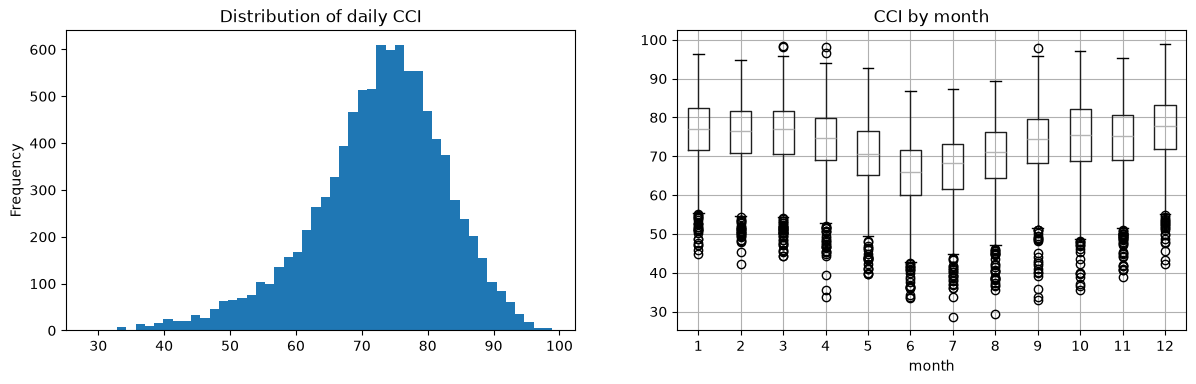

In [115]:
# <Student to fill this section>
print(df_daily['cci'].describe())
print(df_daily['cci'].apply(cci_to_label).value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_daily['cci'].plot(kind='hist', bins=50, ax=axes[0], title='Distribution of daily CCI')
df_daily.assign(month=df_daily['date'].dt.month).boxplot(column='cci', by='month', ax=axes[1])
axes[1].set_title('CCI by month')
plt.suptitle('')
plt.show()

In [116]:
for lag in [1, 2, 3, 7, 365]:
    print(f"Autocorrelation lag {lag}: {df_daily['cci'].autocorr(lag=lag):.3f}")

Autocorrelation lag 1: 0.605
Autocorrelation lag 2: 0.376
Autocorrelation lag 3: 0.289
Autocorrelation lag 7: 0.201
Autocorrelation lag 365: 0.149


In [117]:
# <Student to fill this section>
target_distribution_explanations = """
Distribution: Sydney is mostly comfortable. Out of 9,497 days, 6,271 are Comfortable (60-79), 2,191 are
Excellent (80-100), 983 are Moderate (40-59) and only 52 are Poor (20-39). No day falls in the Very poor band
(minimum CCI 28.6, maximum 98.9). The target is therefore concentrated between 40 and 100, and the model has
little data to learn the rare low-comfort days.

Seasonality: comfort is highest in summer (December 76.9 and January 76.4 on average) and lowest in winter
(June 65.0 and July 66.7). Winter days in Sydney are further from the ideal 22 degC, which lowers the
temperature score, the component with the largest weight (0.35).

Autocorrelation: today's CCI is moderately related to tomorrow's (0.605), but the relationship weakens quickly
(0.376 at 2 days, 0.289 at 3 days, 0.201 at 7 days). This means:
- the day-1 forecast should be the most accurate and the day-3 forecast noticeably less accurate;
- lag and rolling features should help, especially for day 1;
- a simple persistence forecast will degrade quickly with the horizon.

Limitations: the CCI is a deterministic formula of daily averages, so short but severe events (e.g. a 1-hour
storm) are smoothed out. The upper range is capped at 100 and the lower range is rarely reached in Sydney.
"""

In [118]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `cloud_cover`

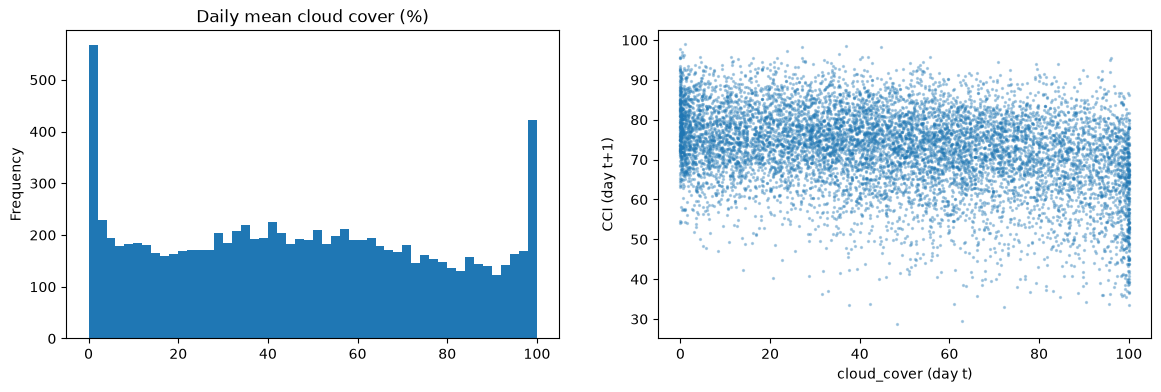

In [119]:
# <Student to fill this section>
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_daily['cloud_cover'].plot(kind='hist', bins=50, ax=axes[0], title='Daily mean cloud cover (%)')
axes[1].scatter(df_daily['cloud_cover'], df_daily['cci_t_plus_1'], s=2, alpha=0.3)
axes[1].set_xlabel('cloud_cover (day t)')
axes[1].set_ylabel('CCI (day t+1)')
plt.show()

In [120]:
print(f"Correlation with same-day CCI: {df_daily['cloud_cover'].corr(df_daily['cci']):.3f}")
print(f"Correlation with next-day CCI: {df_daily['cloud_cover'].corr(df_daily['cci_t_plus_1']):.3f}")

Correlation with same-day CCI: -0.644
Correlation with next-day CCI: -0.320


In [121]:
# <Student to fill this section>
feature_1_insights = """
Cloud cover has the strongest same-day relationship with the CCI among the raw weather variables
(correlation -0.644): cloudy days are less comfortable, both directly (CloudScore) and because cloud usually
comes with rain and humidity.

The relationship with next-day CCI is much weaker (-0.320), showing that today's cloud only partly predicts
tomorrow's comfort. The scatter plot confirms a downward trend with a lot of spread: fully overcast days are
followed by a wide range of CCI values, including most of the lowest ones (below 40).

Distribution: the histogram is U-shaped, with two peaks at completely clear days (0 percent, about 570 days)
and fully overcast days (100 percent, about 420 days), and a flat spread in between. The daily mean is
therefore not normally distributed, which suits tree-based models better than linear ones.

Limitation: a daily mean hides the timing of cloud (a cloudy morning and a sunny afternoon give the same value).
Rolling averages of cloud cover over 3 to 30 days are used to capture persistent cloudy periods.
"""

In [122]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `precipitation`

Share of dry days: 0.507
0.50     0.0
0.90     5.8
0.99    29.7
Name: precipitation, dtype: float64
precipitation
False    75.0
True     70.1
Name: cci_t_plus_1, dtype: float64


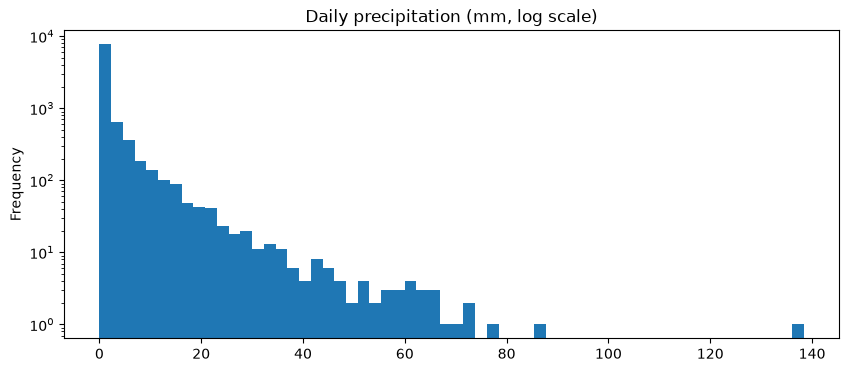

In [123]:
# <Student to fill this section>
print(f"Share of dry days: {(df_daily['precipitation'] == 0).mean():.3f}")
print(df_daily['precipitation'].quantile([0.5, 0.9, 0.99]).round(1))
print(df_daily.groupby(df_daily['precipitation'] > 0)['cci_t_plus_1'].mean().round(1))

df_daily['precipitation'].plot(kind='hist', bins=60, figsize=(10, 4), log=True,
                               title='Daily precipitation (mm, log scale)')
plt.show()

In [124]:
# <Student to fill this section>
feature_2_insights = """
Precipitation is highly skewed: 50.7 percent of days are completely dry, the median is 0.0 mm, 90 percent of
days have 5.8 mm or less, and only 1 percent exceed 29.7 mm (maximum 138.4 mm). A log scale is needed to see
the distribution.

Rain lowers the CCI through the RainScore (20 mm or more gives a score of 0) and is strongly linked to humidity
and cloud. Its same-day correlation with CCI is -0.584 and the number of rainy hours has an even stronger link
(-0.674). Rain also carries over to the next day: the average CCI the day after a wet day is 70.1, compared
with 75.0 after a dry day.

Limitation: the rain component uses daily totals, so it does not distinguish a short shower from a full day of
rain. Rolling rainfall totals over 3 to 30 days are added to capture wet spells. Tree-based models are not
affected by the skewed distribution, so no log transformation is needed.
"""

In [125]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `month` (seasonality)

In [126]:
# <Student to fill this section>
monthly = df_daily.groupby(df_daily['date'].dt.month)['cci'].agg(['mean', 'std']).round(1)
monthly.T

date,1,2,3,4,5,6,7,8,9,10,11,12
mean,76.4,75.4,75.3,73.8,70.0,65.0,66.7,69.6,73.6,74.6,74.0,76.9
std,8.8,9.0,9.5,9.1,9.3,9.3,9.1,9.6,9.9,10.6,10.2,9.0


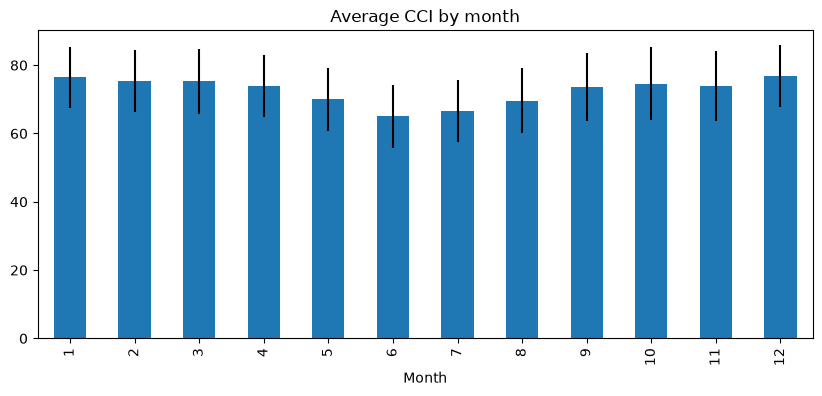

In [127]:
monthly['mean'].plot(kind='bar', yerr=monthly['std'], figsize=(10, 4), title='Average CCI by month')
plt.xlabel('Month')
plt.show()

In [128]:
# <Student to fill this section>
feature_n_insights = """
The average CCI changes clearly with the season: December (76.9), January (76.4) and February (75.4) have the
highest average comfort, and June (65.0), July (66.7) and August (69.6) the lowest, a difference of about
12 points between summer and winter. This seasonal pattern is the basis of the climatology baseline and is
captured in the model through cyclical day-of-year features (doy_sin, doy_cos) and the month.

Seasonality explains only part of the variation: the standard deviation within each month (8.8 to 10.6 points)
is almost as large as the difference between summer and winter. Day-to-day weather therefore still causes large
changes in comfort, which the lag and rolling features aim to capture.
"""

In [129]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

---
## D. Feature Selection



### D.1 Approach "Correlation with next-day CCI (training years only)"

In [130]:
# <Student to fill this section>
train_period = df_daily['date'] < '2020-01-01'
base_cols = [c for c in df_daily.columns if c not in ['date', 'whc'] + target_cols]

corr_next_day = (df_daily.loc[train_period, base_cols]
                 .corrwith(df_daily.loc[train_period, 'cci_t_plus_1'])
                 .sort_values(key=abs, ascending=False))
corr_next_day.round(3)

cci                         0.596
shortwave_radiation         0.464
temperature_2m_max          0.381
relative_humidity_2m       -0.342
temperature_2m              0.342
precipitation_hours        -0.338
whi                        -0.312
cloud_cover                -0.307
apparent_temperature        0.285
pressure_msl_min           -0.257
rain                       -0.253
precipitation              -0.253
pressure_msl               -0.248
temperature_2m_min          0.244
relative_humidity_2m_max   -0.177
cloud_cover_max            -0.176
wind_gusts_10m              0.138
wind_speed_10m_max          0.114
dew_point_2m                0.093
wind_speed_10m              0.022
snowfall                      NaN
dtype: float64

In [131]:
# <Student to fill this section>
feature_selection_1_insights = """
The correlation between each daily variable and the next-day CCI was calculated on the training years only
(2000-2019), so the validation and test periods do not influence which features are kept.

Results: today's CCI is the strongest predictor (0.596), followed by solar radiation (0.464), daily maximum
temperature (0.381), relative humidity (-0.342), mean temperature (0.342), precipitation hours (-0.338) and
today's WHI (-0.312). Correlations are weaker than the same-day correlations because the target is one day in
the future.

Wind speed has almost no linear correlation (0.022). This is expected, because the WindScore is not linear:
it is highest at 10 km/h and decreases for both calmer and windier days. A linear correlation cannot capture
this shape, which is one of the reasons for testing a tree-based model in this experiment.

No variable was removed on correlation alone: a weak linear correlation does not mean a variable is useless.
XGBoost selects the most useful features itself when choosing its splits, and features that never help are
simply not used.
"""

In [132]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### D.2 Approach "Remove constant and duplicate variables"

In [133]:
# <Student to fill this section>
print(df_daily[['snowfall', 'rain', 'precipitation']].describe().T[['mean', 'std', 'max']])
print("rain identical to precipitation:", np.allclose(df_daily['rain'], df_daily['precipitation']))

                   mean       std    max
snowfall       0.000000  0.000000    0.0
rain           2.159324  6.148343  138.4
precipitation  2.159324  6.148343  138.4
rain identical to precipitation: True


In [134]:
# <Student to fill this section>
feature_selection_2_insights = """
snowfall is always 0 in Sydney (standard deviation 0). A constant variable carries no information, so it is
removed from the features. It is still used inside the target formulas as required, but contributes 0 there.

rain is identical to precipitation, because all precipitation in Sydney falls as rain. Keeping both would give
the model the same information twice and split the feature importance between two identical columns, making it
harder to interpret, so rain is removed and precipitation is kept.
"""

In [135]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

## D.z Final Selection of Features



In [136]:
# <Student to fill this section>

features_list = [c for c in base_cols if c not in ['snowfall', 'rain']]
print(len(features_list))
features_list

19


['temperature_2m',
 'relative_humidity_2m',
 'wind_speed_10m',
 'cloud_cover',
 'precipitation',
 'wind_gusts_10m',
 'temperature_2m_max',
 'temperature_2m_min',
 'relative_humidity_2m_max',
 'wind_speed_10m_max',
 'cloud_cover_max',
 'precipitation_hours',
 'dew_point_2m',
 'apparent_temperature',
 'pressure_msl',
 'pressure_msl_min',
 'shortwave_radiation',
 'cci',
 'whi']

In [137]:
# <Student to fill this section>
feature_selection_explanations = """
The 19 base daily variables kept are: the 5 CCI inputs (temperature, humidity, wind speed, cloud cover,
precipitation), wind gusts, daily min and max temperature, max humidity, max wind speed, max cloud cover,
precipitation hours, dew point, apparent temperature, mean and min sea-level pressure, solar radiation, and
today's CCI and WHI.

Section F adds engineered features built from these base variables (lags, rolling windows, pressure change,
calendar features), giving the final feature set used for modelling.
"""

In [138]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Data Transformation `Missing days and values check`

In [139]:
# <Student to fill this section>
full_range = pd.date_range(df_daily['date'].min(), df_daily['date'].max(), freq='D')
print(f"Missing days: {len(full_range.difference(df_daily['date']))}")
print(f"Missing values in base features: {df_daily[features_list].isna().sum().sum()}")

Missing days: 0
Missing values in base features: 0


In [140]:
# <Student to fill this section>
data_cleaning_1_explanations = """
Lag, rolling and future-target features are created by shifting rows, so every row must be exactly one day
apart. A missing day would silently misalign features and targets (e.g. a lag-1 value coming from two days
before). The check confirms 0 missing days and 0 missing values across 9,497 days, so no imputation is needed.
The build_features function also enforces one row per calendar day as a safeguard.
"""

In [141]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Data Transformation `Exclude production data (2026 onwards)`

In [142]:
# <Student to fill this section>
assert df_daily['date'].max() <= pd.Timestamp('2025-12-31')
print("No 2026 data in the experiment dataset")

No 2026 data in the experiment dataset


In [143]:
# <Student to fill this section>
data_cleaning_2_explanations = """
Data from 2026 onwards represents production data and must not be accessible during the project. Only data
up to 31 December 2025 was downloaded, and this check guarantees it. Future targets for the last 3 days of 2025
would need 2026 values, so those rows have missing targets and are removed before modelling.
"""

In [144]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Data Transformation `Physical range check`

In [145]:
# <Student to fill this section>
df_daily[features_list].describe().T[['min', 'max']]

,min,max
temperature_2m,7.625000,30.904167
relative_humidity_2m,23.875000,96.041667
wind_speed_10m,3.308333,37.387500
cloud_cover,0.000000,100.000000
precipitation,0.000000,138.400000
wind_gusts_10m,12.600000,102.200000
temperature_2m_max,10.000000,42.000000
temperature_2m_min,1.100000,27.100000
relative_humidity_2m_max,34.000000,100.000000
wind_speed_10m_max,5.100000,48.800000


In [146]:
# <Student to fill this section>
data_cleaning_3_explanations = """
Each variable was checked against physically plausible ranges. All values are plausible for Sydney: humidity
between 24 and 96 percent (daily mean), cloud cover between 0 and 100 percent, no negative precipitation or
wind speed, daily mean temperature between 7.6 and 30.9 degC (maximum 42.0 degC on heatwave days), sea-level
pressure between 991.5 and 1037.7 hPa, and wind gusts up to 102.2 km/h.

The largest daily rainfall (138.4 mm) and the strongest gusts are extreme but realistic storm events. Open-Meteo
historical data is a quality-controlled reanalysis product, so no outlier removal was applied. These extreme
days must be kept, because they are exactly the conditions that matter most for comfort and hazard.
"""

In [147]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 New Feature "Lag, rolling and calendar features (build_features)"

In [148]:
# <Student to fill this section>
df_features = build_features(df_daily)
feature_cols = get_feature_columns(df_features)

print(df_features.shape)
print(f"{len(feature_cols)} features")

(9497, 96)
92 features


In [149]:
# <Student to fill this section>
feature_engineering_1_explanations = """
All engineered features are created by build_features() from the custom package (my_krml_26044382 v0.0.5).
The same function is used by the deployed API, so production features are guaranteed to match training.

Features created (all use only information available at the end of day t, so there is no leakage):
- Lags of 1, 2, 3 and 7 days for CCI, WHI, temperature, humidity, precipitation, cloud cover, wind speed,
  wind gusts and pressure.
- Rolling means over 3, 7, 14 and 30 days for CCI, WHI, temperature, humidity, cloud cover and wind gusts.
- Rolling rainfall totals over 3, 7, 14 and 30 days.
- Calendar features: month, day of year, day of week and a cyclical encoding (sin and cos of day of year), so
  that 31 December and 1 January are close to each other.
- Daily temperature range and 1-day and 3-day pressure change (Section F.2).

The first 29 days of 2000 lack a complete 30-day history and are removed before modelling.
"""

In [150]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 New Feature "Pressure change"

In [151]:
# <Student to fill this section>
pressure_cols = ['pressure_msl_change_1d', 'pressure_msl_change_3d']
print(df_features[pressure_cols].describe().round(2))
print(df_features[pressure_cols].corrwith(df_features['cci_t_plus_1']).round(3))

       pressure_msl_change_1d  pressure_msl_change_3d
count                 9496.00                 9494.00
mean                    -0.00                   -0.00
std                      4.43                    7.90
min                    -17.08                  -31.50
25%                     -2.99                   -5.41
50%                     -0.16                   -0.22
75%                      2.88                    5.22
max                     17.99                   33.80
pressure_msl_change_1d   -0.035
pressure_msl_change_3d   -0.053
dtype: float64


In [152]:
# <Student to fill this section>
feature_engineering_2_explanations = """
The change in sea-level pressure over 1 and 3 days is a classic forecasting signal: falling pressure usually
indicates an approaching front or low-pressure system bringing cloud, wind and rain, while rising pressure
indicates clearing, settled weather. The absolute pressure level alone does not capture this trend.

The pressure changes vary widely (standard deviation 4.4 hPa over 1 day and 7.9 hPa over 3 days), but their
linear correlation with next-day CCI is very weak (-0.035 and -0.053), and in Experiment 2 they did not appear
among the 10 most important XGBoost features. They are kept because tree models ignore unhelpful features, and
their contribution is checked again in the feature importance of the final model.
"""

In [153]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 New Feature "Lag and rolling window signals"

In [154]:
# <Student to fill this section>
lag_roll = ['cci', 'cci_lag_1', 'cci_lag_7', 'cci_roll7_mean', 'cci_roll30_mean',
            'precipitation_roll7_sum', 'doy_cos']
df_features[lag_roll].corrwith(df_features['cci_t_plus_1']).round(3)

cci                        0.605
cci_lag_1                  0.376
cci_lag_7                  0.195
cci_roll7_mean             0.451
cci_roll30_mean            0.385
precipitation_roll7_sum   -0.153
doy_cos                    0.337
dtype: float64

In [155]:
# <Student to fill this section>
feature_engineering_n_explanations = """
This compares how strongly each lag or rolling feature relates to next-day CCI. Today's CCI is the strongest
(0.605), followed by the 7-day rolling mean (0.451), the 30-day rolling mean (0.385), the 1-day lag (0.376)
and the seasonal encoding doy_cos (0.337). The 7-day lag is weaker (0.195) and the 7-day rainfall total is
negatively related (-0.153).

Rolling means are stronger than single lags because they smooth out daily noise and capture the current weather
regime (e.g. a wet or cool spell). This is especially useful for the 2 and 3 day horizons, where today's value
alone loses predictive power. The seasonal encoding captures the time-of-year effect seen in Section C.7.
"""

In [156]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Data Preparation for Modeling



### G.1 Split Datasets

In [157]:
# <Student to fill this section>
df_model = df_features.dropna(subset=feature_cols + target_cols).reset_index(drop=True)

X_train, y_train, X_val, y_val, X_test, y_test = split_sets_by_time(
    df_model[feature_cols], df_model[target_cols], df_model['date'],
    val_start='2020-01-01', test_start='2023-01-01', gap=3
)

for name, X in [('train', X_train), ('val', X_val), ('test', X_test)]:
    d = df_model.loc[X.index, 'date']
    print(f"{name}: {len(X)} rows, {d.min().date()} to {d.max().date()}")

train: 7273 rows, 2000-01-30 to 2019-12-28
val: 1093 rows, 2020-01-01 to 2022-12-28
test: 1093 rows, 2023-01-01 to 2025-12-28


In [158]:
# <Student to fill this section>
data_splitting_explanations = """
A chronological split is used instead of a random split. With time series, a random split would put days from
the future in the training set and neighbouring, highly correlated days in both training and validation, which
leaks information and gives overly optimistic results.

- Training: 30 Jan 2000 to 28 Dec 2019 (20 years, covering many seasonal cycles)
- Validation: 2020 to 2022 (used by Optuna to tune the hyperparameters and to choose the sample weights)
- Testing: 2023 to 2025 (used once, for the final evaluation in this experiment)

A 3-day gap is removed at the end of the training and validation periods. Without it, the targets of the last
training days (CCI 1 to 3 days later) would be calculated from validation days.

After tuning, the model is retrained on training plus validation (2000-2022) and evaluated on the test period,
which gives an honest estimate of performance on unseen years. The deployed model is then retrained on all
available data (2000-2025) with the same settings.
"""

In [159]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Data Transformation "Standard scaling (not required)"

In [160]:
# <Student to fill this section>
X_train[['pressure_msl', 'precipitation', 'doy_sin']].describe().loc[['mean', 'std']].round(2)

,pressure_msl,precipitation,doy_sin
mean,1017.20,1.81,-0.00
std,6.67,5.32,0.71


In [161]:
# <Student to fill this section>
data_transformation_1_explanations = """
The features are on very different scales (pressure around 1015 hPa, precipitation mostly 0 to 20 mm, cyclical
features between -1 and 1). Unlike Ridge in Experiment 1, XGBoost does not need scaling: decision trees split
each feature on a threshold, and the position of a threshold does not depend on the feature's scale. Scaling
would not change the model, so it is not applied. This also keeps the deployed model simpler, because the API
can pass the raw features directly.
"""

In [162]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 Data Transformation "Categorical encoding (not required)"

In [163]:
# <Student to fill this section>
non_numeric = X_train.select_dtypes(exclude='number').columns.tolist()
print(f"Non-numeric features: {non_numeric}")

Non-numeric features: []


In [164]:
# <Student to fill this section>
data_transformation_2_explanations = """
All features are numeric, including the calendar features (month, day of year, day of week), so no categorical
encoding is required. The month is kept as a number because the cyclical features doy_sin and doy_cos already
represent the seasonal cycle smoothly, and one-hot encoding 12 months would add many sparse columns.
"""

In [165]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Data Transformation "Missing value imputation (not required)"

In [166]:
# <Student to fill this section>
print(f"Missing values - train: {X_train.isna().sum().sum()}, val: {X_val.isna().sum().sum()}, test: {X_test.isna().sum().sum()}")

Missing values - train: 0, val: 0, test: 0


In [167]:
# <Student to fill this section>
data_transformation_3_explanations = """
No imputation is required. The raw data has no missing days or values, and the only missing values created by
feature engineering (the first 29 days without a full 30-day history) and by the future targets (the last 3 days
of 2025) were removed before splitting. Removing them is preferable to imputing, because an imputed lag or target
would be invented data.
"""

In [168]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

---
## H. Save Datasets

In [169]:
# <Student to fill this section>

data_final_path = '../../data/processed/cci_exp3'
os.makedirs(data_final_path, exist_ok=True)

In [170]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(f'{data_final_path}/X_train.csv', index=False)
  y_train.to_csv(f'{data_final_path}/y_train.csv', index=False)

  X_val.to_csv(f'{data_final_path}/X_val.csv', index=False)
  y_val.to_csv(f'{data_final_path}/y_val.csv', index=False)

  X_test.to_csv(f'{data_final_path}/X_test.csv', index=False)
  y_test.to_csv(f'{data_final_path}/y_test.csv', index=False)
except Exception as e:
  print(e)

---
## I. Selection of Performance Metrics

> Provide some explanations on why you believe the performance metrics you chose is appropriate




In [171]:
# <Student to fill this section>
dates_val = df_model.loc[X_val.index, 'date']
dates_test = df_model.loc[X_test.index, 'date']
train_dates = df_model.loc[X_train.index, 'date']
monthly_climatology = df_model.loc[X_train.index].groupby(train_dates.dt.month)['cci'].mean()

def uncomfortable_missed(pred, actual, threshold=60):
    """Share of uncomfortable days (actual CCI below threshold) forecast as comfortable"""
    actual = np.asarray(actual)
    pred = np.asarray(pred)
    uncomfortable = actual < threshold
    return (pred[uncomfortable] >= threshold).mean()

baseline_scores = {}
for h, col in enumerate(target_cols, start=1):
    print(f"\n--- {col} ---")
    persistence = X_val['cci']
    target_month = (dates_val + pd.to_timedelta(h, unit='D')).dt.month
    climatology = target_month.map(monthly_climatology)
    baseline_scores[(col, 'persistence')] = print_regressor_scores(persistence, y_val[col], 'Val persistence')
    baseline_scores[(col, 'climatology')] = print_regressor_scores(climatology, y_val[col], 'Val climatology')


--- cci_t_plus_1 ---
RMSE Val persistence: 9.7002
MAE Val persistence: 7.2418
R2 Val persistence: 0.1915
RMSE Val climatology: 11.2111
MAE Val climatology: 8.3456
R2 Val climatology: -0.0800

--- cci_t_plus_2 ---
RMSE Val persistence: 12.0999
MAE Val persistence: 9.3472
R2 Val persistence: -0.2585
RMSE Val climatology: 11.2144
MAE Val climatology: 8.3525
R2 Val climatology: -0.0811

--- cci_t_plus_3 ---
RMSE Val persistence: 13.2635
MAE Val persistence: 10.3232
R2 Val persistence: -0.5121
RMSE Val climatology: 11.2140
MAE Val climatology: 8.3512
R2 Val climatology: -0.0809


In [172]:
# <Student to fill this section>
performance_metrics_explanations = """
Four metrics are used:
- RMSE (main accuracy metric): average error in CCI points, penalising large errors more.
- MAE: average absolute error in CCI points, easy to explain to stakeholders.
- R2: share of the variation in CCI explained by the model.
- Uncomfortable days missed (business metric added after Experiment 2): the share of days with an actual CCI
  below 60 that were forecast at 60 or above. This is the most costly error for event planning.

Tuning and model choices use the validation set (2020-2022), where the baselines score: persistence RMSE 9.70,
12.10 and 13.26, climatology RMSE 11.21 for all horizons, and Experiment 2 XGBoost 8.52, 10.08 and 10.62.

The final model is then evaluated once on the test set (2023-2025) against Ridge, persistence and climatology,
all refitted on 2000-2022 so that the comparison is fair.
"""

In [173]:
# Do not modify this code
print_tile(size="h3", key='performance_metrics_explanations', value=performance_metrics_explanations)

## J. Train Machine Learning Model

### J.1 Import Algorithm

> Provide some explanations on why you believe this algorithm is a good fit


In [174]:
# <Student to fill this section>
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [175]:
# <Student to fill this section>
algorithm_selection_explanations = """
XGBoost is kept from Experiment 2: it was slightly better than Ridge for day 1 and on the business metrics, and
it offers the tuning options needed to address its weaknesses (regularisation against overfitting, and sample
weights to focus on uncomfortable days).

Optuna is used for hyperparameter tuning. Instead of trying every combination of a fixed grid, it uses a
Bayesian search (Tree-structured Parzen Estimator) that learns from previous trials which areas of the search
space are promising. This lets it explore 7 hyperparameters efficiently, which a grid search could not do in a
reasonable time.

Ridge regression (Experiment 1) is refitted in this notebook only as a comparison on the test set.
"""

In [176]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### J.2 Set Hyperparameters

> Provide some explanations on why you believe this algorithm is a good fit


In [177]:
# <Student to fill this section>
N_TRIALS = 40

def make_objective(col):
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 2, 6),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 30),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        }
        model = XGBRegressor(n_estimators=1500, early_stopping_rounds=50, random_state=42, n_jobs=4, **params)
        model.fit(X_train, y_train[col], eval_set=[(X_val, y_val[col])], verbose=False)
        trial.set_user_attr('n_estimators', model.best_iteration + 1)
        return model.best_score
    return objective

best_params = {}
for col in target_cols:
    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(make_objective(col), n_trials=N_TRIALS)
    best_params[col] = {**study.best_params, 'n_estimators': study.best_trial.user_attrs['n_estimators']}
    print(f"{col}: best validation RMSE {study.best_value:.3f} with {best_params[col]}")

cci_t_plus_1: best validation RMSE 8.494 with {'max_depth': 4, 'learning_rate': 0.04664781184099544, 'min_child_weight': 5, 'subsample': 0.6317584904957341, 'colsample_bytree': 0.8470491229477027, 'reg_lambda': 0.061058812623966036, 'gamma': 3.151033666185458, 'n_estimators': 242}
cci_t_plus_2: best validation RMSE 10.062 with {'max_depth': 3, 'learning_rate': 0.01993034072242506, 'min_child_weight': 16, 'subsample': 0.64600789544468, 'colsample_bytree': 0.9533609543605671, 'reg_lambda': 0.763421475836254, 'gamma': 2.613487400096382, 'n_estimators': 533}
cci_t_plus_3: best validation RMSE 10.557 with {'max_depth': 3, 'learning_rate': 0.19571589252638139, 'min_child_weight': 27, 'subsample': 0.8213829773615509, 'colsample_bytree': 0.4738168731017742, 'reg_lambda': 0.0011194988999715346, 'gamma': 0.11101368777578324, 'n_estimators': 43}


In [178]:
# Sample weights: give more importance to uncomfortable days (actual CCI below 60) during training
weight_options = [1, 2, 3, 5]
weight_results = []

for col in target_cols:
    for w in weight_options:
        weights = np.where(y_train[col] < 60, w, 1.0)
        model = XGBRegressor(random_state=42, n_jobs=4, **best_params[col])
        model.fit(X_train, y_train[col], sample_weight=weights)
        pred = model.predict(X_val)
        weight_results.append({
            'target': col,
            'weight': w,
            'val_rmse': np.sqrt(np.mean((pred - y_val[col]) ** 2)),
            'uncomfortable_missed': uncomfortable_missed(pred, y_val[col]),
        })

weight_results = pd.DataFrame(weight_results)
print(weight_results.pivot(index='weight', columns='target', values=['val_rmse', 'uncomfortable_missed']).round(3))

# Rule: lowest share of missed uncomfortable days, while keeping RMSE within 2 percent of the unweighted model
chosen_weights = {}
for col in target_cols:
    res = weight_results[weight_results['target'] == col]
    rmse_limit = 1.02 * res.loc[res['weight'] == 1, 'val_rmse'].iloc[0]
    acceptable = res[res['val_rmse'] <= rmse_limit]
    chosen_weights[col] = int(acceptable.sort_values(['uncomfortable_missed', 'val_rmse']).iloc[0]['weight'])
chosen_weights

           val_rmse                           uncomfortable_missed  \
target cci_t_plus_1 cci_t_plus_2 cci_t_plus_3         cci_t_plus_1   
weight                                                               
1             8.494       10.062       10.557                0.789   
2             8.404        9.813       10.475                0.679   
3             8.445        9.738       10.353                0.647   
5             8.524        9.792       10.495                0.546   

                                  
target cci_t_plus_2 cci_t_plus_3  
weight                            
1             0.995        1.000  
2             0.963        0.991  
3             0.931        0.982  
5             0.826        0.876  


{'cci_t_plus_1': 5, 'cci_t_plus_2': 5, 'cci_t_plus_3': 5}

In [179]:
# <Student to fill this section>
hyperparameters_selection_explanations = """
Optuna tuned 7 XGBoost hyperparameters for each horizon (40 trials each), minimising validation RMSE:
- max_depth (2 to 6) and learning_rate (0.01 to 0.2): model complexity and learning speed, as in Experiment 2.
- min_child_weight (1 to 30), reg_lambda (0.001 to 10) and gamma (0 to 5): regularisation parameters added to
  reduce the overfitting seen in Experiment 2, by preventing splits on very few days and penalising large leaf
  values.
- subsample (0.6 to 1) and colsample_bytree (0.4 to 1): randomness in rows and features for each tree.
- n_estimators: chosen with early stopping (up to 1,500 trees).

Best settings (validation RMSE):
- Day 1: 8.494 (max_depth 4, learning_rate 0.047, min_child_weight 5, gamma 3.15, 242 trees)
- Day 2: 10.062 (max_depth 3, learning_rate 0.020, min_child_weight 16, gamma 2.61, 533 trees)
- Day 3: 10.557 (max_depth 3, learning_rate 0.196, min_child_weight 27, 43 trees)
Optuna prefers shallow trees with strong regularisation (a high gamma or min_child_weight), which fits noisy
targets. The gain over the grid search of Experiment 2 (8.523, 10.076, 10.618) is only 0.1 to 0.6 percent,
confirming that accuracy is limited by the information in the features rather than by the hyperparameters.

Sample weights: uncomfortable training days (CCI below 60) were given a weight of 1, 2, 3 or 5. The rule
selects the weight with the fewest missed uncomfortable days while keeping the validation RMSE within 2 percent
of the unweighted model. Weight 5 was chosen for all horizons. On validation, it reduced the share of
uncomfortable days forecast as comfortable from 78.9 to 54.6 percent (day 1), 99.5 to 82.6 percent (day 2) and
100 to 87.6 percent (day 3), with RMSE 8.524, 9.792 and 10.495.

The weights also improved the validation RMSE for days 2 and 3. This is because the validation years
(2020-2022) were unusually wet, with more uncomfortable days than the training years, so shifting forecasts
downwards happened to suit this period. Section J.4 checks whether this holds on the test period.
"""

In [180]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### J.3 Fit Model

In [181]:
# <Student to fill this section>
# 1. Retrain on training + validation (2000-2022) for the final evaluation on the test set (2023-2025)
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

test_models = {}
for col in target_cols:
    weights = np.where(y_trainval[col] < 60, chosen_weights[col], 1.0)
    test_models[col] = XGBRegressor(random_state=42, n_jobs=4, **best_params[col])
    test_models[col].fit(X_trainval, y_trainval[col], sample_weight=weights)

# Ridge from Experiment 1, refitted on the same period for a fair comparison
ridge_models = {}
for col in target_cols:
    exp1_file = f'../../models/comfort_climate/cci_exp1_ridge_{col}.joblib'
    alpha = load(exp1_file).named_steps['ridge'].alpha if os.path.exists(exp1_file) else 10.0
    ridge_models[col] = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=alpha))])
    ridge_models[col].fit(X_trainval, y_trainval[col])

# 2. Retrain on all available data (2000-2025) with the same settings: these are the deployed models
X_all = df_model[feature_cols]
y_all = df_model[target_cols]

final_models = {}
os.makedirs('../../models/comfort_climate', exist_ok=True)
for col in target_cols:
    weights = np.where(y_all[col] < 60, chosen_weights[col], 1.0)
    final_models[col] = XGBRegressor(random_state=42, n_jobs=4, **best_params[col])
    final_models[col].fit(X_all, y_all[col], sample_weight=weights)
    dump(final_models[col], f'../../models/comfort_climate/cci_xgb_{col}.joblib')

print("Saved deployment models:", [f'cci_xgb_{col}.joblib' for col in target_cols])

Saved deployment models: ['cci_xgb_cci_t_plus_1.joblib', 'cci_xgb_cci_t_plus_2.joblib', 'cci_xgb_cci_t_plus_3.joblib']


### J.4 Model Technical Performance

> Provide some explanations on model performance



===== cci_t_plus_1 (test 2023-2025) =====
RMSE XGBoost (final): 8.8491
MAE XGBoost (final): 6.9398
R2 XGBoost (final): 0.3348
RMSE Ridge: 8.3868
MAE Ridge: 6.3368
R2 Ridge: 0.4025
RMSE persistence: 9.7979
MAE persistence: 7.4702
R2 persistence: 0.1845
RMSE climatology: 10.1452
MAE climatology: 7.5951
R2 climatology: 0.1257

===== cci_t_plus_2 (test 2023-2025) =====
RMSE XGBoost (final): 10.3263
MAE XGBoost (final): 8.2948
R2 XGBoost (final): 0.0942
RMSE Ridge: 9.4841
MAE Ridge: 7.1129
R2 Ridge: 0.2359
RMSE persistence: 12.0587
MAE persistence: 9.2263
R2 persistence: -0.2352
RMSE climatology: 10.1452
MAE climatology: 7.5952
R2 climatology: 0.1257

===== cci_t_plus_3 (test 2023-2025) =====
RMSE XGBoost (final): 10.7980
MAE XGBoost (final): 8.7416
R2 XGBoost (final): 0.0080
RMSE Ridge: 9.8399
MAE Ridge: 7.4013
R2 Ridge: 0.1763
RMSE persistence: 12.8910
MAE persistence: 9.8653
R2 persistence: -0.4138
RMSE climatology: 10.1436
MAE climatology: 7.5927
R2 climatology: 0.1246

Test RMSE:
targ

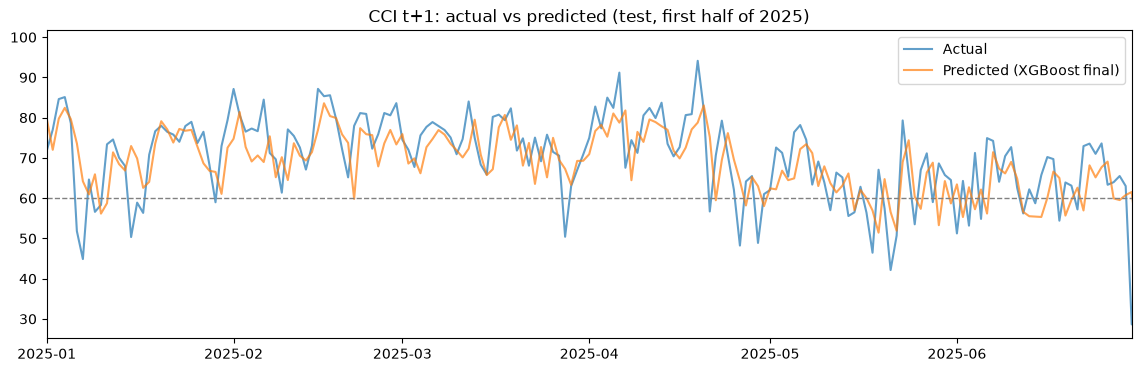

In [182]:
# <Student to fill this section>
test_train_dates = df_model.loc[X_trainval.index, 'date']
test_climatology = df_model.loc[X_trainval.index].groupby(test_train_dates.dt.month)['cci'].mean()

test_results = []
for h, col in enumerate(target_cols, start=1):
    actual = y_test[col]
    predictions = {
        'XGBoost (final)': test_models[col].predict(X_test),
        'Ridge': ridge_models[col].predict(X_test),
        'persistence': X_test['cci'].values,
        'climatology': (dates_test + pd.to_timedelta(h, unit='D')).dt.month.map(test_climatology).values,
    }
    print(f"\n===== {col} (test 2023-2025) =====")
    for name, pred in predictions.items():
        scores = print_regressor_scores(pred, actual, name)
        test_results.append({'target': col, 'model': name, **scores,
                             'uncomfortable_missed': uncomfortable_missed(pred, actual)})

test_results = pd.DataFrame(test_results)
os.makedirs('../../reports', exist_ok=True)
test_results.to_csv('../../reports/cci_exp3_test_results.csv', index=False)

print("\nTest RMSE:")
print(test_results.pivot(index='model', columns='target', values='rmse').round(3))
print("\nTest share of uncomfortable days missed:")
print(test_results.pivot(index='model', columns='target', values='uncomfortable_missed').round(3))

print("\nTop 10 features (deployed t+1 model):")
for name, value in get_feature_importance(final_models['cci_t_plus_1'], feature_cols, top_n=10).items():
    print(f"{name:30s} {value:.4f}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(dates_test, y_test['cci_t_plus_1'], label='Actual', alpha=0.7)
ax.plot(dates_test, test_models['cci_t_plus_1'].predict(X_test), label='Predicted (XGBoost final)', alpha=0.7)
ax.axhline(60, color='grey', linestyle='--', linewidth=1)
ax.set_xlim(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-06-30'))
ax.set_title('CCI t+1: actual vs predicted (test, first half of 2025)')
ax.legend()
plt.show()

In [183]:
# <Student to fill this section>
model_performance_explanations = """
Final evaluation on the unseen test period (2023-2025), with all models refitted on 2000-2022 (RMSE):
- Day 1: Ridge 8.39, XGBoost 8.85, persistence 9.80, climatology 10.15
- Day 2: Ridge 9.48, XGBoost 10.33, persistence 12.06, climatology 10.15
- Day 3: Ridge 9.84, XGBoost 10.80, persistence 12.89, climatology 10.14

Ridge is the most accurate model at every horizon and beats the best baseline by 14.4, 6.5 and 3.0 percent
(R2 0.40, 0.24 and 0.18). The tuned and weighted XGBoost beats the baselines only for day 1 (by 9.7 percent).
For day 2 and day 3 it is worse than simply forecasting the monthly average (by 1.8 and 6.5 percent), with an
R2 close to 0 for day 3.

Consistency with validation: Ridge performs better on the test period than on validation (8.59, 10.04 and
10.52), as do the baselines (climatology 11.21 to 10.14), because 2023-2025 were less extreme than the wet
2020-2022 period. XGBoost, however, lost ground. Its sample weight (5) was chosen on the unusually wet
validation years, where pushing forecasts downwards helped. On the more typical test years, the same downward
push lowers forecasts on normal days. The plot shows this: in February 2025, actual comfort of 75-87 is forecast
at around 70-78. This shows the risk of tuning on a period that is not representative.

Uncomfortable days (CCI below 60, 163 test days) forecast as comfortable: XGBoost 57.7, 63.2 and 68.1 percent,
compared with Ridge 75.5, 93.9 and 99.4 percent. The weighting achieved its goal on this metric, at the cost of
overall accuracy.

Feature importance (deployed XGBoost, day 1): today's CCI (0.149) and its 3-day rolling mean (0.067) dominate,
followed by solar radiation (0.037). All other features contribute between 0.012 and 0.015, confirming across
all three experiments that recent comfort and sunshine are the key signals.
"""

In [184]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### J.5 Business Impact from Current Model Performance

> Provide some analysis on the model impacts from the business point of view


In [185]:
# <Student to fill this section>
business_rows = []
for col in target_cols:
    for name, model in [('XGBoost (final)', test_models[col]), ('Ridge', ridge_models[col])]:
        pred = model.predict(X_test)
        actual = y_test[col].values
        abs_err = np.abs(pred - actual)
        band_pred = pd.Series(pred).apply(cci_to_label).values
        band_actual = pd.Series(actual).apply(cci_to_label).values
        business_rows.append({
            'target': col,
            'model': name,
            'within_5_points': (abs_err <= 5).mean(),
            'within_10_points': (abs_err <= 10).mean(),
            'correct_band': (band_pred == band_actual).mean(),
            'uncomfortable_days': int((actual < 60).sum()),
            'uncomfortable_missed': uncomfortable_missed(pred, actual),
        })

business_results = pd.DataFrame(business_rows).set_index(['target', 'model']).round(3)
business_results

within_5_points  within_10_points  correct_band  \
target       model                                                              
cci_t_plus_1 XGBoost (final)            0.441             0.757         0.653   
             Ridge                      0.503             0.801         0.681   
cci_t_plus_2 XGBoost (final)            0.357             0.666         0.628   
             Ridge                      0.471             0.750         0.664   
cci_t_plus_3 XGBoost (final)            0.340             0.629         0.597   
             Ridge                      0.452             0.744         0.657   

                              uncomfortable_days  uncomfortable_missed  
target       model                                                      
cci_t_plus_1 XGBoost (final)                 163                 0.577  
             Ridge                           163                 0.755  
cci_t_plus_2 XGBoost (final)                 163                 0.632  
             Ridge                           163                 0.939  
cci_t_plus_3 XGBoost (final)                 163                 0.681  
             Ridge                           163                 0.994

In [186]:
# Save the model metadata used by the API /model-metadata endpoint
xgb_test = test_results[test_results['model'] == 'XGBoost (final)'].set_index('target')

cci_metadata = {
    'target': 'Climate Comfort Index',
    'prediction_type': 'Regression',
    'algorithm': 'XGBoost Regressor',
    'forecast_horizon': '3 Days',
    'output_range': '0-100',
    'location': {'city': 'Sydney', 'latitude': -33.8688, 'longitude': 151.2093},
    'training_period': f"{df_model['date'].min().date()} to {df_model['date'].max().date()}",
    'package_version': package_version,
    'required_history_days': REQUIRED_HISTORY_DAYS,
    'features': feature_cols,
    'feature_importance': get_feature_importance(final_models['cci_t_plus_1'], feature_cols, top_n=15),
    'models': {
        col: {
            'file': f'cci_xgb_{col}.joblib',
            'horizon_days': h,
            'hyperparameters': best_params[col],
            'uncomfortable_day_weight': chosen_weights[col],
            'test_performance_2023_2025': {
                'rmse': round(float(xgb_test.loc[col, 'rmse']), 3),
                'mae': round(float(xgb_test.loc[col, 'mae']), 3),
                'r2': round(float(xgb_test.loc[col, 'r2']), 3),
                'uncomfortable_days_missed': round(float(xgb_test.loc[col, 'uncomfortable_missed']), 3),
            },
        }
        for h, col in enumerate(target_cols, start=1)
    },
}

with open('../../models/comfort_climate/cci_metadata.json', 'w') as f:
    json.dump(cci_metadata, f, indent=2)
print(json.dumps({k: v for k, v in cci_metadata.items() if k not in ['features']}, indent=2)[:2500])

{
  "target": "Climate Comfort Index",
  "prediction_type": "Regression",
  "algorithm": "XGBoost Regressor",
  "forecast_horizon": "3 Days",
  "output_range": "0-100",
  "location": {
    "city": "Sydney",
    "latitude": -33.8688,
    "longitude": 151.2093
  },
  "training_period": "2000-01-30 to 2025-12-28",
  "package_version": "0.0.5",
  "required_history_days": 29,
  "feature_importance": {
    "cci": 0.149,
    "cci_roll3_mean": 0.0668,
    "shortwave_radiation": 0.037,
    "precipitation": 0.0151,
    "temperature_2m_max": 0.0149,
    "whi": 0.0144,
    "cloud_cover": 0.0141,
    "temperature_2m_roll14_mean": 0.0135,
    "temperature_2m_roll7_mean": 0.0129,
    "cci_roll30_mean": 0.0126,
    "relative_humidity_2m": 0.0126,
    "cci_roll7_mean": 0.0124,
    "pressure_msl_min": 0.0123,
    "temperature_2m_roll3_mean": 0.0119,
    "precipitation_hours": 0.0117
  },
  "models": {
    "cci_t_plus_1": {
      "file": "cci_xgb_cci_t_plus_1.joblib",
      "horizon_days": 1,
      "hype

In [193]:
# Final model selection: Ridge is deployed for the CCI API
# (best test accuracy at every horizon, and the only model that beats both baselines on 2023-2025)
deploy_models = {}
for col in target_cols:
    alpha = ridge_models[col].named_steps['ridge'].alpha
    deploy_models[col] = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge(alpha=alpha))])
    deploy_models[col].fit(X_all, y_all[col])
    dump(deploy_models[col], f'../../models/comfort_climate/cci_ridge_{col}.joblib')

# Feature importance for Ridge: absolute standardised coefficients, normalised to sum to 1
all_importance = get_feature_importance(deploy_models['cci_t_plus_1'].named_steps['ridge'], feature_cols)
total = sum(all_importance.values())
ridge_importance = {name: round(value / total, 4) for name, value in list(all_importance.items())[:15]}

ridge_test = test_results[test_results['model'] == 'Ridge'].set_index('target')

cci_metadata = {
    'target': 'Climate Comfort Index',
    'prediction_type': 'Regression',
    'algorithm': 'Ridge Regression (StandardScaler + Ridge pipeline)',
    'forecast_horizon': '3 Days',
    'output_range': '0-100',
    'location': {'city': 'Sydney', 'latitude': -33.8688, 'longitude': 151.2093},
    'training_period': f"{df_model['date'].min().date()} to {df_model['date'].max().date()}",
    'package_version': package_version,
    'required_history_days': REQUIRED_HISTORY_DAYS,
    'features': feature_cols,
    'feature_importance': ridge_importance,
    'models': {
        col: {
            'file': f'cci_ridge_{col}.joblib',
            'horizon_days': h,
            'hyperparameters': {'alpha': float(deploy_models[col].named_steps['ridge'].alpha)},
            'test_performance_2023_2025': {
                'rmse': round(float(ridge_test.loc[col, 'rmse']), 3),
                'mae': round(float(ridge_test.loc[col, 'mae']), 3),
                'r2': round(float(ridge_test.loc[col, 'r2']), 3),
                'uncomfortable_days_missed': round(float(ridge_test.loc[col, 'uncomfortable_missed']), 3),
            },
        }
        for h, col in enumerate(target_cols, start=1)
    },
    'test_rmse_comparison_2023_2025': {
        model: {col: round(float(v), 3) for col, v in rows.items()}
        for model, rows in test_results.pivot(index='model', columns='target', values='rmse').iterrows()
    },
    'limitations': 'Accuracy decreases with the horizon (lowest for day 3), and uncomfortable days '
                   '(CCI below 60) are often forecast as comfortable.',
}

with open('../../models/comfort_climate/cci_metadata.json', 'w') as f:
    json.dump(cci_metadata, f, indent=2)

print("Saved deployment models:", [f'cci_ridge_{col}.joblib' for col in target_cols])
print(json.dumps({k: v for k, v in cci_metadata.items() if k != 'features'}, indent=2))

Saved deployment models: ['cci_ridge_cci_t_plus_1.joblib', 'cci_ridge_cci_t_plus_2.joblib', 'cci_ridge_cci_t_plus_3.joblib']
{
  "target": "Climate Comfort Index",
  "prediction_type": "Regression",
  "algorithm": "Ridge Regression (StandardScaler + Ridge pipeline)",
  "forecast_horizon": "3 Days",
  "output_range": "0-100",
  "location": {
    "city": "Sydney",
    "latitude": -33.8688,
    "longitude": 151.2093
  },
  "training_period": "2000-01-30 to 2025-12-28",
  "package_version": "0.0.5",
  "required_history_days": 29,
  "feature_importance": {
    "cci": 0.0852,
    "temperature_2m": 0.0811,
    "apparent_temperature": 0.0764,
    "pressure_msl_min": 0.0526,
    "whi": 0.0445,
    "cloud_cover": 0.0367,
    "doy_cos": 0.0254,
    "temperature_2m_roll3_mean": 0.0249,
    "dew_point_2m": 0.0214,
    "cci_roll3_mean": 0.0213,
    "pressure_msl_lag_1": 0.0206,
    "pressure_msl": 0.0201,
    "cci_lag_1": 0.0199,
    "wind_speed_10m_max": 0.0198,
    "whi_lag_1": 0.0196
  },
  "mode

In [187]:
# <Student to fill this section>
business_impacts_explanations = """
Forecast quality on the test period (2023-2025), Ridge vs XGBoost (weighted):
- Within 5 CCI points: Ridge 50.3, 47.1, 45.2 percent vs XGBoost 44.1, 35.7, 34.0 percent (days 1, 2, 3)
- Within 10 CCI points: Ridge 80.1, 75.0, 74.4 percent vs XGBoost 75.7, 66.6, 62.9 percent
- Correct interpretation band: Ridge 68.1, 66.4, 65.7 percent vs XGBoost 65.3, 62.8, 59.7 percent
- Uncomfortable days missed: Ridge 75.5, 93.9, 99.4 percent vs XGBoost 57.7, 63.2, 68.1 percent

The two models serve different business needs:
- Ridge gives the most accurate everyday forecast: 4 in 5 day-1 forecasts are within 10 points and 2 in 3 are
  in the correct band. It is the best choice for a general comfort forecast shown to users.
- XGBoost with weights is better at warning about uncomfortable days, but gives less accurate values on normal
  days and is worse than the seasonal average for days 2 and 3.

Decision: Ridge is deployed in the API, because it is the only model that meets the success criterion (beating
both baselines at every horizon on unseen data), and it is simple, fast and fully explainable. Users should be
told that day-1 forecasts are the most reliable, and that the service does not reliably warn about
uncomfortable days, especially for days 2 and 3. For use cases where missing a poor day is very costly (e.g.
large outdoor events), the weighted XGBoost could be offered later as a separate risk-alert option, or the
Weather Hazard Category service can be used alongside.
"""

In [188]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Project Outcomes


In [189]:
# <Student to fill this section>
experiment_outcome = "Hypothesis Partially Confirmed"  # Either 'Hypothesis Confirmed', 'Hypothesis Partially Confirmed' or 'Hypothesis Rejected'

In [190]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [191]:
# <Student to fill this section>
experiment_results_explanations = """
Outcome: the hypothesis is partially confirmed.
- Confirmed: giving more weight to uncomfortable days reduced the share of uncomfortable days missed, both on
  validation (from 78.9 to 54.6 percent for day 1) and on the unseen test period (57.7 percent vs 75.5 percent
  for Ridge), with a validation RMSE equal to or better than Experiment 2.
- Not confirmed: on the test period (2023-2025), the model does not beat Ridge at any horizon (RMSE 8.85, 10.33
  and 10.80 vs 8.39, 9.48 and 9.84), and it is worse than climatology for days 2 and 3.

Key insights across the three experiments:
- Accuracy is limited by the information in local daily weather history. Ridge, XGBoost with a grid search and
  XGBoost with Optuna all reach similar accuracy, and tuning brings less than 1 percent improvement.
- The simplest model (Ridge) generalises best to new years.
- Choices tuned on the validation period (here the sample weight) can fail if that period is not
  representative. The wet 2020-2022 years favoured forecasts shifted downwards, which did not hold in 2023-2025.
- There is a trade-off between overall accuracy and detecting uncomfortable days, which is a business decision.

Final decision: Ridge regression, retrained on all data from 2000 to 2025, is deployed for the CCI API
(files cci_ridge_cci_t_plus_1/2/3.joblib and cci_metadata.json).

Recommended next steps:
1. Monitor forecast errors on 2026 production data and retrain regularly (e.g. every year), since the weather
   regime changes between periods.
2. Build a dedicated classification model for uncomfortable-day alerts, with a decision threshold chosen with
   the business, instead of relying on a regression model.
3. Add information beyond local history (e.g. numerical weather forecasts or large-scale climate indices such
   as ENSO), the most promising way to improve days 2 and 3.
4. Choose sample weights and thresholds using several past periods (rolling validation) rather than a single
   validation window, to avoid the overfitting to one regime seen in this experiment.
"""

In [192]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)